In [1]:
# ============================================================
# CELLULE 1 — Exploration DDR
# But : comprendre la structure sur disque avant tout traitement
# ============================================================
import os
from pathlib import Path
from collections import Counter

DATA_DIR = Path('/kaggle/input/datasets/samriddhibagchi/ddr-dataset-credits-to-authors')

# ── 1. Arborescence brute (2 niveaux) ───────────────────────
print("=== Arborescence (profondeur 2) ===")
for p in sorted(DATA_DIR.rglob('*')):
    depth = len(p.relative_to(DATA_DIR).parts)
    if depth <= 2:
        indent = '  ' * (depth - 1)
        print(f"{indent}{p.name}{'/' if p.is_dir() else ''}")

# ── 2. Compter les fichiers par dossier ─────────────────────
print("\n=== Nombre de fichiers par sous-dossier ===")
for folder in sorted(DATA_DIR.rglob('*')):
    if folder.is_dir():
        files = list(folder.iterdir())
        n_files = sum(1 for f in files if f.is_file())
        if n_files > 0:
            exts = Counter(f.suffix.lower() for f in files if f.is_file())
            print(f"  {folder.relative_to(DATA_DIR)} : {n_files} fichiers {dict(exts)}")

# ── 3. Chercher les fichiers de labels (txt, csv) ───────────
print("\n=== Fichiers de labels potentiels ===")
for ext in ['.txt', '.csv', '.json']:
    for f in DATA_DIR.rglob(f'*{ext}'):
        print(f"  {f.relative_to(DATA_DIR)}")

# ── 4. Inspecter le contenu d'un fichier label ──────────────
print("\n=== Aperçu des fichiers .txt trouvés ===")
for txt_file in list(DATA_DIR.rglob('*.txt'))[:3]:
    print(f"\n--- {txt_file.relative_to(DATA_DIR)} (10 premières lignes) ---")
    with open(txt_file) as f:
        for i, line in enumerate(f):
            if i >= 10: break
            print(f"  {repr(line.rstrip())}")

# ── 5. Inspecter quelques images (taille, mode) ─────────────
print("\n=== Aperçu de quelques images ===")
from PIL import Image as PILImage
img_files = list(DATA_DIR.rglob('*.jpg'))[:5] + list(DATA_DIR.rglob('*.png'))[:5]
for img_path in img_files[:6]:
    try:
        img = PILImage.open(img_path)
        print(f"  {img_path.relative_to(DATA_DIR)} : {img.size} {img.mode}")
    except Exception as e:
        print(f"  {img_path.name} : ERREUR {e}")

=== Arborescence (profondeur 2) ===
DDR-dataset/
  DR_grading/
  lesion_detection/
  lesion_segmentation/

=== Nombre de fichiers par sous-dossier ===
  DDR-dataset/DR_grading : 3 fichiers {'.txt': 3}
  DDR-dataset/DR_grading/test : 4105 fichiers {'.jpg': 4105}
  DDR-dataset/DR_grading/train : 6835 fichiers {'.jpg': 6835}
  DDR-dataset/DR_grading/valid : 2733 fichiers {'.jpg': 2733}
  DDR-dataset/lesion_detection/test : 225 fichiers {'.xml': 225}
  DDR-dataset/lesion_detection/train : 383 fichiers {'.xml': 383}
  DDR-dataset/lesion_detection/valid : 149 fichiers {'.xml': 149}
  DDR-dataset/lesion_segmentation/test/image : 225 fichiers {'.jpg': 225}
  DDR-dataset/lesion_segmentation/test/label/EX : 225 fichiers {'.tif': 225}
  DDR-dataset/lesion_segmentation/test/label/HE : 225 fichiers {'.tif': 225}
  DDR-dataset/lesion_segmentation/test/label/MA : 225 fichiers {'.tif': 225}
  DDR-dataset/lesion_segmentation/test/label/SE : 225 fichiers {'.tif': 225}
  DDR-dataset/lesion_segmentation/t

Split      Total  Classes présentes
train       6835  [0]No DR=3133  [1]Mild=315  [2]Moderate=2238  [3]Severe=118  [4]Proliferative=456  [5]Ungradable=575
valid       2733  [0]No DR=1253  [1]Mild=126  [2]Moderate=895  [3]Severe=47  [4]Proliferative=182  [5]Ungradable=230
test        4105  [0]No DR=1880  [1]Mild=189  [2]Moderate=1344  [3]Severe=71  [4]Proliferative=275  [5]Ungradable=346
TOTAL      13673

Classes : [0, 1, 2, 3, 4, 5]
Noms    : ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative', 'Ungradable']

--- Tâche binaire rDR (grade < 2 → 0, grade >= 2 → 1) ---
  train : neg=3448  pos=3387  pos%=49.6%
  valid : neg=1379  pos=1354  pos%=49.5%
  test  : neg=2069  pos=2036  pos%=49.6%

--- Vérification cohérence fichiers / labels ---
  train : 6835 labels, 6835 images, 0 manquants
  valid : 2733 labels, 2733 images, 0 manquants
  test  : 4105 labels, 4105 images, 0 manquants

--- Résolutions (échantillon 50 images train) ---
  2048x1536 : 10 images
  2592x1728 : 9 images
  2304x1

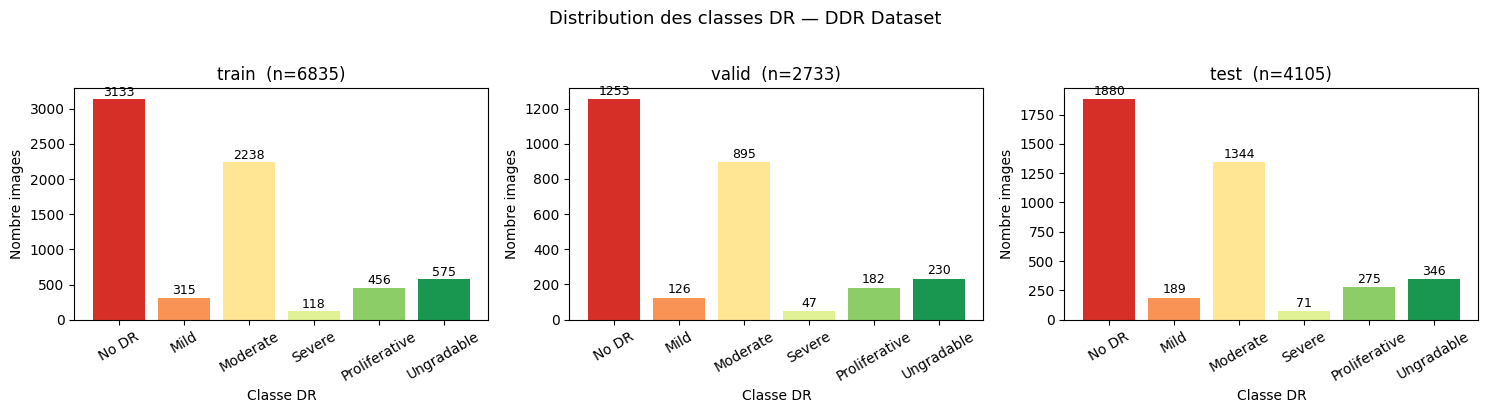


--- Exemples par classe (train) ---


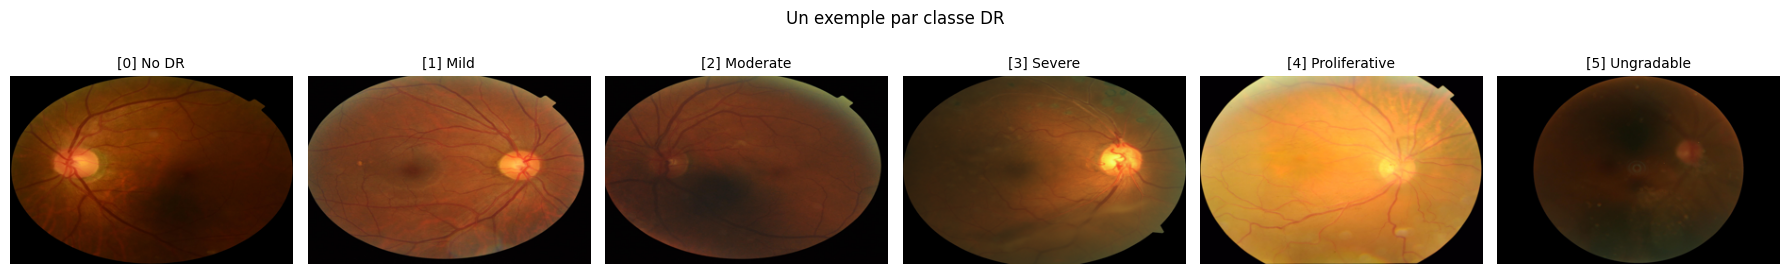

In [2]:
# ============================================================
# CELLULE 2 — Distribution des classes + statistiques globales
# ============================================================
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image as PILImage

DATA_DIR  = Path('/kaggle/input/datasets/samriddhibagchi/ddr-dataset-credits-to-authors/DDR-dataset')
GRAD_DIR  = DATA_DIR / 'DR_grading'

CLASS_NAMES = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative',
    5: 'Ungradable'   # présent dans certaines versions DDR
}

# ── 1. Lire les trois fichiers de labels ────────────────────
def load_labels(txt_path):
    samples = []
    with open(txt_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            fname, label = parts[0], int(parts[1])
            samples.append((fname, label))
    return samples

splits = {
    'train': load_labels(GRAD_DIR / 'train.txt'),
    'valid': load_labels(GRAD_DIR / 'valid.txt'),
    'test':  load_labels(GRAD_DIR / 'test.txt'),
}

# ── 2. Statistiques par split ────────────────────────────────
print("=" * 55)
print(f"{'Split':<8} {'Total':>7}  {'Classes présentes'}")
print("=" * 55)

all_counts = {}
for split, samples in splits.items():
    counter  = Counter(lbl for _, lbl in samples)
    all_counts[split] = counter
    classes  = sorted(counter.keys())
    detail   = '  '.join(f"[{c}]{CLASS_NAMES.get(c,'?')}={counter[c]}" for c in classes)
    print(f"{split:<8} {len(samples):>7}  {detail}")

total_all = sum(len(s) for s in splits.values())
print("=" * 55)
print(f"{'TOTAL':<8} {total_all:>7}")

# ── 3. Classes présentes dans le dataset ─────────────────────
all_labels = set()
for s in splits.values():
    all_labels.update(lbl for _, lbl in s)
print(f"\nClasses : {sorted(all_labels)}")
print(f"Noms    : {[CLASS_NAMES.get(c,'?') for c in sorted(all_labels)]}")

# ── 4. Tâche binaire rDR (referable DR : grade >= 2) ─────────
print("\n--- Tâche binaire rDR (grade < 2 → 0, grade >= 2 → 1) ---")
for split, samples in splits.items():
    neg = sum(1 for _, l in samples if l < 2)
    pos = sum(1 for _, l in samples if l >= 2)
    ratio = pos / (neg + pos) * 100
    print(f"  {split:<6}: neg={neg}  pos={pos}  pos%={ratio:.1f}%")

# ── 5. Vérification fichiers manquants ──────────────────────
print("\n--- Vérification cohérence fichiers / labels ---")
for split, samples in splits.items():
    img_dir  = GRAD_DIR / split
    missing  = [f for f, _ in samples if not (img_dir / f).exists()]
    print(f"  {split:<6}: {len(samples)} labels, "
          f"{len(list(img_dir.glob('*.jpg')))} images, "
          f"{len(missing)} manquants")

# ── 6. Résolutions des images (échantillon) ──────────────────
print("\n--- Résolutions (échantillon 50 images train) ---")
train_imgs = list((GRAD_DIR / 'train').glob('*.jpg'))[:50]
sizes = []
for p in train_imgs:
    try:
        w, h = PILImage.open(p).size
        sizes.append((w, h))
    except:
        pass
unique_sizes = Counter(sizes)
for sz, cnt in unique_sizes.most_common(10):
    print(f"  {sz[0]}x{sz[1]} : {cnt} images")

# ── 7. Visualisation distribution ────────────────────────────
labels_list = sorted(all_labels)
colors      = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(labels_list)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (split, counter) in zip(axes, all_counts.items()):
    counts = [counter.get(l, 0) for l in labels_list]
    bars   = ax.bar([CLASS_NAMES.get(l, str(l)) for l in labels_list],
                    counts, color=colors)
    ax.set_title(f'{split}  (n={sum(counts)})', fontsize=12)
    ax.set_xlabel('Classe DR')
    ax.set_ylabel('Nombre images')
    ax.tick_params(axis='x', rotation=30)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(cnt), ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribution des classes DR — DDR Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── 8. Visualisation exemples par classe ─────────────────────
print("\n--- Exemples par classe (train) ---")
train_samples = splits['train']
by_class      = {}
for fname, lbl in train_samples:
    by_class.setdefault(lbl, []).append(fname)

fig, axes = plt.subplots(1, len(labels_list), figsize=(3 * len(labels_list), 3))
for ax, lbl in zip(axes, labels_list):
    candidates = by_class.get(lbl, [])
    if not candidates:
        ax.axis('off'); continue
    img_path = GRAD_DIR / 'train' / candidates[0]
    try:
        img = PILImage.open(img_path).convert('RGB')
        img_resized = img.resize((300, 200))
        ax.imshow(img_resized)
    except:
        ax.axis('off')
    ax.set_title(f"[{lbl}] {CLASS_NAMES.get(lbl,'?')}", fontsize=10)
    ax.axis('off')

plt.suptitle('Un exemple par classe DR', fontsize=12)
plt.tight_layout()
plt.show()